<a href="https://colab.research.google.com/github/ksjones21-bit/program-budget-forecast-analysis/blob/main/program_budget_forecast_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataframe

In [ ]:
import pandas as pd

data = {
    "Program": [
        "Admin",
        "Health Services",
        "Community Programs",
        "Child Services",
        "Housing Support"
    ],
    "Budget": [500000, 1200000, 800000, 600000, 400000],
    "Actual_YTD": [275000, 700000, 500000, 350000, 260000],
    "Months_Elapsed": [6, 6, 6, 6, 6]
}

df = pd.DataFrame(data)
df

,Program,Budget,Actual_YTD,Months_Elapsed
0,Admin,500000,275000,6
1,Health Services,1200000,700000,6
2,Community Programs,800000,500000,6
3,Child Services,600000,350000,6
4,Housing Support,400000,260000,6


Forecast

In [ ]:
df["Monthly_Actual"] = df["Actual_YTD"] / df["Months_Elapsed"]

df["Forecast"] = df["Monthly_Actual"] * 12

Variance Analysis

In [ ]:
df["Variance"] = df["Forecast"] - df["Budget"]

df["Variance_%"] = df["Variance"] / df["Budget"]



Visualization

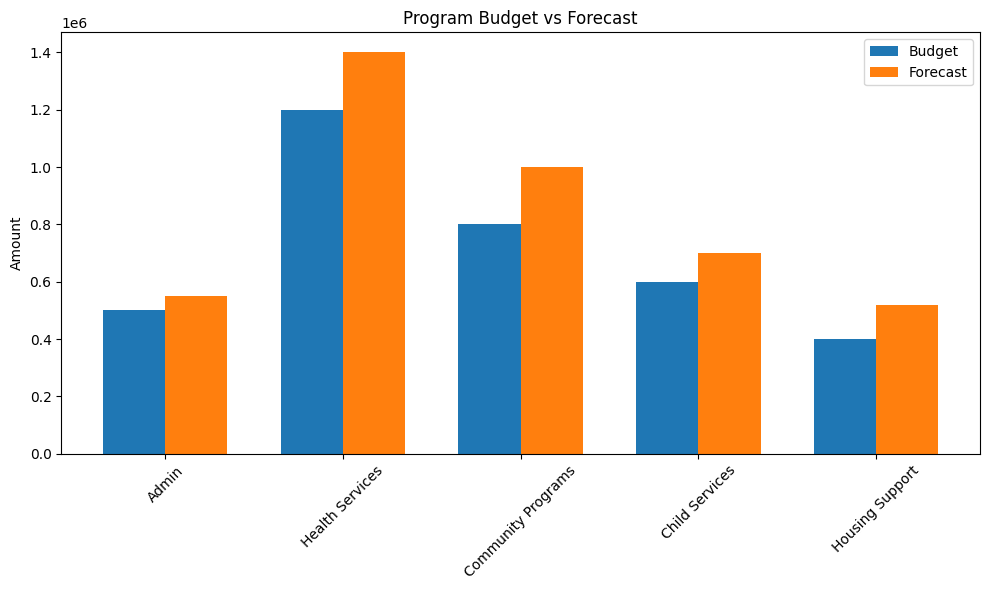

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(df["Program"]))  # positions
width = 0.35  # bar width

plt.figure(figsize=(10,6))

plt.bar(x - width/2, df["Budget"], width, label="Budget")
plt.bar(x + width/2, df["Forecast"], width, label="Forecast")

plt.xticks(x, df["Program"], rotation=45)

plt.title("Program Budget vs Forecast")
plt.ylabel("Amount")
plt.legend()

plt.tight_layout()
plt.show()

Decisions

In [ ]:
# Rebuild clean numeric table for decisions
decision_df = pd.DataFrame({
    "Program": [
        "Admin",
        "Health Services",
        "Community Programs",
        "Child Services",
        "Housing Support"
    ],
    "Budget": [500000, 1200000, 800000, 600000, 400000],
    "Actual_YTD": [275000, 700000, 500000, 350000, 260000],
    "Months_Elapsed": [6, 6, 6, 6, 6]
})

# Calculations
decision_df["Monthly_Actual"] = decision_df["Actual_YTD"] / decision_df["Months_Elapsed"]
decision_df["Forecast"] = decision_df["Monthly_Actual"] * 12
decision_df["Variance"] = decision_df["Forecast"] - decision_df["Budget"]
decision_df["Variance_%"] = decision_df["Variance"] / decision_df["Budget"]
decision_df["Status"] = decision_df["Variance"].apply(
    lambda x: "Over Budget" if x > 0 else "Under Budget"
)

# Format for presentation
currency_cols = ["Budget", "Actual_YTD", "Monthly_Actual", "Forecast", "Variance"]
for col in currency_cols:
    decision_df[col] = decision_df[col].map(lambda x: f"${x:,.0f}")

decision_df["Variance_%"] = decision_df["Variance_%"].map(lambda x: f"{x:.1%}")

# Rename columns
decision_df = decision_df.rename(columns={
    "Actual_YTD": "Actual (YTD)",
    "Monthly_Actual": "Monthly Run Rate",
    "Variance_%": "Variance (%)"
})

# Reorder columns
decision_df = decision_df[[
    "Program",
    "Budget",
    "Actual (YTD)",
    "Forecast",
    "Variance",
    "Variance (%)",
    "Status"
]]

decision_df

,Program,Budget,Actual (YTD),Forecast,Variance,Variance (%),Status
0,Admin,"$500,000","$275,000","$550,000","$50,000",10.0%,Over Budget
1,Health Services,"$1,200,000","$700,000","$1,400,000","$200,000",16.7%,Over Budget
2,Community Programs,"$800,000","$500,000","$1,000,000","$200,000",25.0%,Over Budget
3,Child Services,"$600,000","$350,000","$700,000","$100,000",16.7%,Over Budget
4,Housing Support,"$400,000","$260,000","$520,000","$120,000",30.0%,Over Budget


## Key Insights

- All five programs are currently trending over budget based on annualized year-to-date spending.
- Health Services and Community Programs show the largest dollar overruns, making them the highest priority for review.
- Housing Support has the highest percentage variance, suggesting a smaller budget base is being pressured more quickly.
- This type of mid-year reforecast helps leadership identify where intervention, reallocation, or revised assumptions may be needed before year-end.